# CSE457 - XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
## BÀI THỰC HÀNH 1: PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ

**Sinh viên thực hiện:** Nguyễn Văn Minh  
**MSSV:** 2351260673  
**Môn học:** CSE457 - Xử lý âm thanh và tiếng nói  
**Bộ dữ liệu thực nghiệm:** `audio/piano_sample.mp3` (Piano Solo Music)  

---

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pydub import AudioSegment
import soundfile as sf
from scipy import signal

# Cấu hình giao diện đồ thị Matplotlib đồng bộ chuẩn báo cáo
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
os.makedirs('figures', exist_ok=True)
os.makedirs('audio', exist_ok=True)
print("Import thư viện và cấu hình đồ thị thành công!")

Import thư viện và cấu hình đồ thị thành công!


--- 
## KHỐI A: ĐỌC VÀ KIỂM TRA DỮ LIỆU ÂM THANH (AUDIO METADATA & NORMALIZATION)

### Mục tiêu:
1. Đọc tệp âm thanh `audio/piano_sample.mp3`.
2. Trích xuất và phân tích các tham số số hóa: Tần số lấy mẫu ($F_s$), số kênh ($C$), thời lượng ($T$), độ rộng mẫu ($B$), kích thước file và tốc độ bit ($Bitrate$).
3. Chuyển đổi tín hiệu Stereo sang Mono bằng trung bình cộng 2 kênh.
4. Chuẩn hóa biên độ tín hiệu về miền số thực chuẩn $[-1.0, 1.0]$.
5. Đo đạc Peak, RMS và kiểm tra hiện tượng Clipping.

In [2]:
# A.1 & A.2: Đọc file âm thanh và trích xuất Metadata
audio_path = os.path.join('audio', 'piano_sample.mp3')
audio = AudioSegment.from_file(audio_path)

Fs = audio.frame_rate
channels = audio.channels
sample_width = audio.sample_width   # bytes/mẫu
bit_depth = sample_width * 8       # bits/mẫu
duration_sec = len(audio) / 1000.0
total_samples = int(duration_sec * Fs)
file_size_bytes = os.path.getsize(audio_path)

# Tính Bitrate nén thực tế và Bitrate PCM không nén tương đương
bitrate_compressed_kbps = (file_size_bytes * 8) / (duration_sec * 1000)
pcm_bitrate_kbps = (Fs * bit_depth * channels) / 1000.0
pcm_theoretical_size_mb = (pcm_bitrate_kbps * 1000 * duration_sec) / (8 * 1024 * 1024)

print("=" * 60)
print("               BẢNG THÔNG SỐ METADATA TỆP ÂM THANH")
print("=" * 60)
print(f"  Tệp âm thanh                : {os.path.basename(audio_path)}")
print(f"  Tần số lấy mẫu (Fs)         : {Fs:,} Hz")
print(f"  Tần số Nyquist (Fs / 2)     : {Fs / 2:,} Hz")
print(f"  Số kênh âm thanh (Channels) : {channels} ({'Stereo' if channels == 2 else 'Mono'})")
print(f"  Độ rộng mẫu giải mã         : {bit_depth} bit/mẫu ({sample_width} bytes)")
print(f"  Thời lượng (Duration)       : {duration_sec:.3f} giây ({total_samples:,} mẫu)")
print(f"  Dung lượng file MP3         : {file_size_bytes:,} bytes ({file_size_bytes / (1024*1024):.2f} MB)")
print(f"  Tốc độ bit MP3 (Bit rate)   : ~{bitrate_compressed_kbps:.1f} kbps")
print(f"  Tốc độ bit PCM 16-bit stereo: {pcm_bitrate_kbps:.1f} kbps")
print(f"  Dung lượng PCM lý thuyết    : ~{pcm_theoretical_size_mb:.2f} MB")
print("=" * 60)

               BẢNG THÔNG SỐ METADATA TỆP ÂM THANH
  Tệp âm thanh                : piano_sample.mp3
  Tần số lấy mẫu (Fs)         : 48,000 Hz
  Tần số Nyquist (Fs / 2)     : 24,000.0 Hz
  Số kênh âm thanh (Channels) : 2 (Stereo)
  Độ rộng mẫu giải mã         : 16 bit/mẫu (2 bytes)
  Thời lượng (Duration)       : 35.243 giây (1,691,664 mẫu)
  Dung lượng file MP3         : 854,823 bytes (0.82 MB)
  Tốc độ bit MP3 (Bit rate)   : ~194.0 kbps
  Tốc độ bit PCM 16-bit stereo: 1536.0 kbps
  Dung lượng PCM lý thuyết    : ~6.45 MB


In [3]:
# A.3: Tách kênh Stereo, Chuyển sang Mono và Chuẩn hóa về [-1.0, 1.0]
raw_samples = np.array(audio.get_array_of_samples(), dtype=np.float64)
norm_factor = float(2 ** (bit_depth - 1))  # 2^15 = 32768 cho định dạng 16-bit signed int

if channels == 2:
    left_raw = raw_samples[0::2]
    right_raw = raw_samples[1::2]
    x_left = left_raw / norm_factor
    x_right = right_raw / norm_factor
    # Chuyển đổi sang Mono bằng phương pháp trung bình cộng 2 kênh
    x_mono = (x_left + x_right) / 2.0
else:
    x_mono = raw_samples / norm_factor
    x_left = x_mono
    x_right = x_mono

time_axis = np.arange(len(x_mono)) / Fs

print(f"Kích thước mảng tín hiệu Mono: {len(x_mono):,} mẫu")
print(f"Miền giá trị x_mono: [{x_mono.min():.4f}, {x_mono.max():.4f}]")

Kích thước mảng tín hiệu Mono: 1,691,648 mẫu
Miền giá trị x_mono: [-0.4031, 0.4420]


In [4]:
# A.4: Đo đạc Peak, RMS và kiểm tra hiện tượng Clipping
def calc_metrics(sig, name="Signal"):
    peak = float(np.max(np.abs(sig)))
    rms = float(np.sqrt(np.mean(sig ** 2)))
    peak_dbfs = float(20 * np.log10(peak)) if peak > 0 else -np.inf
    rms_dbfs = float(20 * np.log10(rms)) if rms > 0 else -np.inf
    crest_factor = float(peak / rms) if rms > 0 else 0.0
    return {
        "Name": name,
        "Peak": peak,
        "Peak_dBFS": peak_dbfs,
        "RMS": rms,
        "RMS_dBFS": rms_dbfs,
        "Crest_Factor": crest_factor
    }

m_left = calc_metrics(x_left, "Left Channel")
m_right = calc_metrics(x_right, "Right Channel")
m_mono = calc_metrics(x_mono, "Mono (Averaged)")

print("=" * 70)
print(f"{'Kênh':<18} | {'Peak (abs)':<12} | {'Peak (dBFS)':<12} | {'RMS':<10} | {'RMS (dBFS)':<12}")
print("-" * 70)
for m in [m_left, m_right, m_mono]:
    print(f"{m['Name']:<18} | {m['Peak']:<12.4f} | {m['Peak_dBFS']:<12.2f} | {m['RMS']:<10.4f} | {m['RMS_dBFS']:<12.2f}")
print("=" * 70)

# Kiểm tra an toàn biên độ
if m_mono['Peak'] >= 0.9999:
    print("CẢNH BÁO: Tín hiệu có nguy cơ bị Clipping (Peak sát ngưỡng 1.0)!")
else:
    print(f"AN TOÀN: Tín hiệu không bị clipping. Headroom khả dụng: {abs(m_mono['Peak_dBFS']):.2f} dBFS")

Kênh               | Peak (abs)   | Peak (dBFS)  | RMS        | RMS (dBFS)  
----------------------------------------------------------------------
Left Channel       | 0.5555       | -5.11        | 0.0889     | -21.02      
Right Channel      | 0.5417       | -5.33        | 0.0842     | -21.49      
Mono (Averaged)    | 0.4420       | -7.09        | 0.0653     | -23.70      
AN TOÀN: Tín hiệu không bị clipping. Headroom khả dụng: 7.09 dBFS


Đã lưu biểu đồ so sánh vào: figures\partA_stereo_vs_mono.png


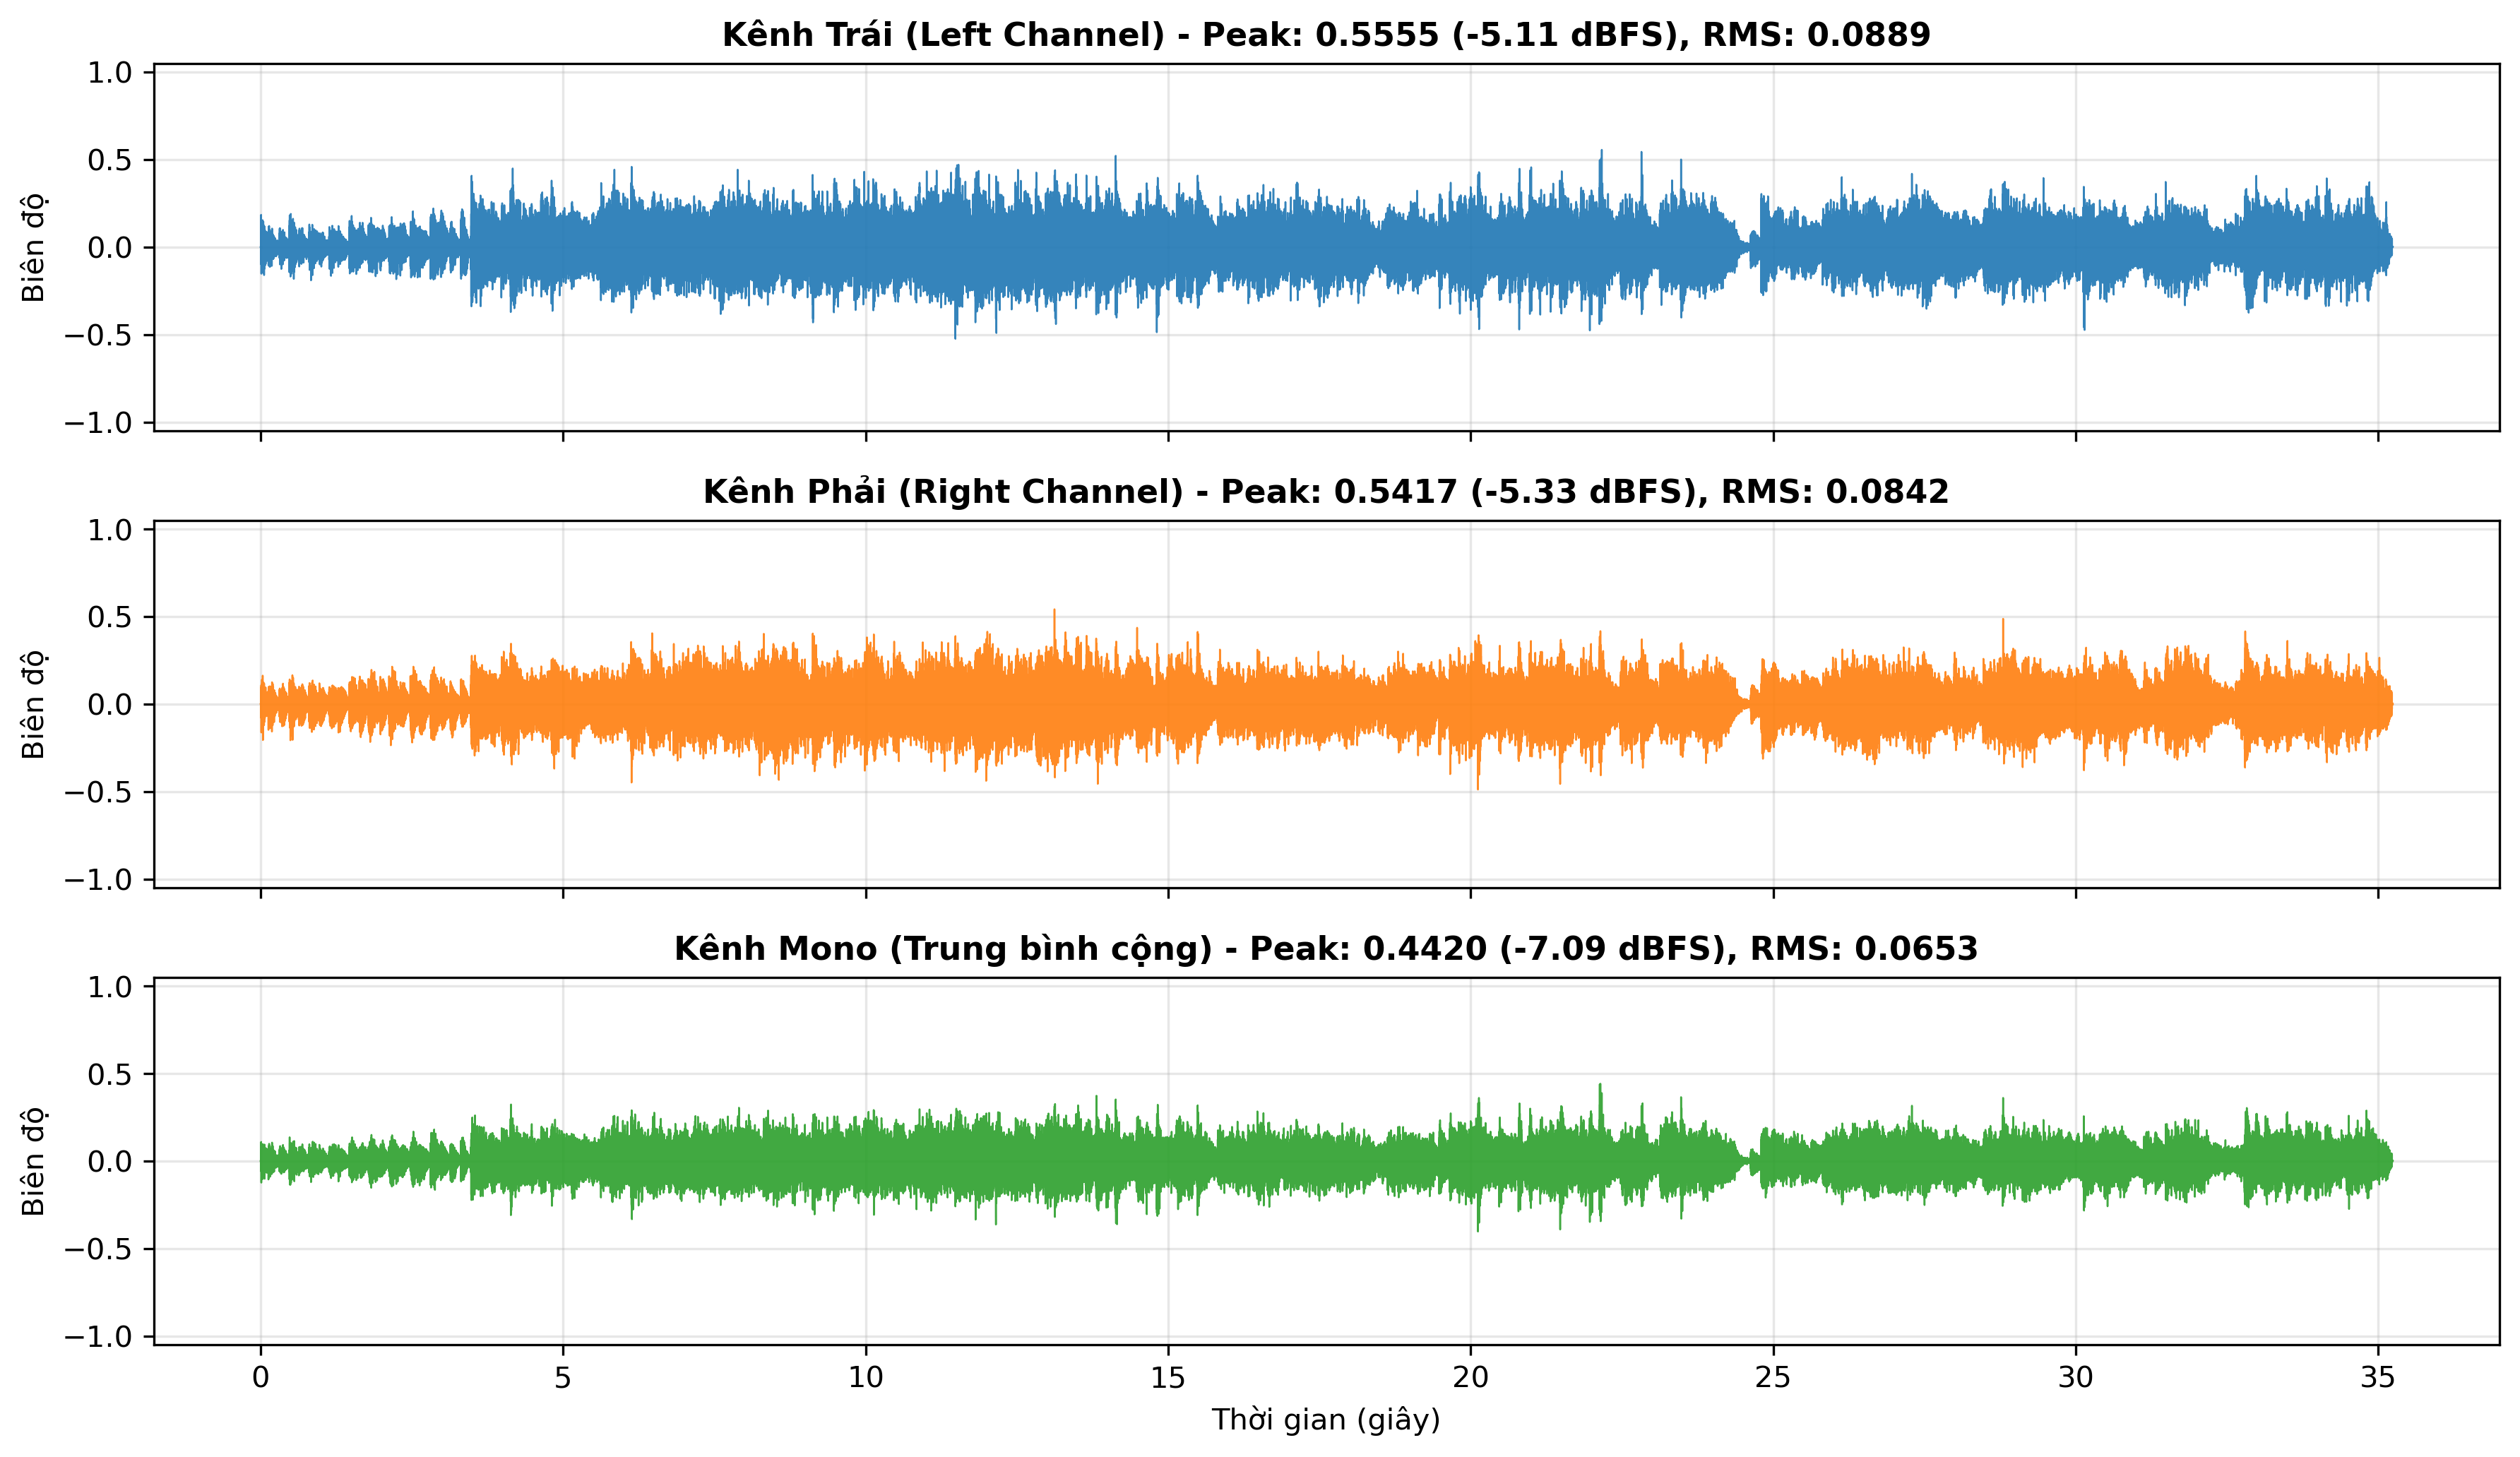

In [5]:
# A.5: Trực quan hóa dạng sóng (Waveform): Left vs Right vs Mono
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(time_axis, x_left, color='#1f77b4', lw=0.6, alpha=0.9)
axes[0].set_title(f"Kênh Trái (Left Channel) - Peak: {m_left['Peak']:.4f} ({m_left['Peak_dBFS']:.2f} dBFS), RMS: {m_left['RMS']:.4f}", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Biên độ", fontsize=10)
axes[0].set_ylim([-1.05, 1.05])
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis, x_right, color='#ff7f0e', lw=0.6, alpha=0.9)
axes[1].set_title(f"Kênh Phải (Right Channel) - Peak: {m_right['Peak']:.4f} ({m_right['Peak_dBFS']:.2f} dBFS), RMS: {m_right['RMS']:.4f}", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Biên độ", fontsize=10)
axes[1].set_ylim([-1.05, 1.05])
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_axis, x_mono, color='#2ca02c', lw=0.6, alpha=0.9)
axes[2].set_title(f"Kênh Mono (Trung bình cộng) - Peak: {m_mono['Peak']:.4f} ({m_mono['Peak_dBFS']:.2f} dBFS), RMS: {m_mono['RMS']:.4f}", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Thời gian (giây)", fontsize=10)
axes[2].set_ylabel("Biên độ", fontsize=10)
axes[2].set_ylim([-1.05, 1.05])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join('figures', 'partA_stereo_vs_mono.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Đã lưu biểu đồ so sánh vào: {fig_path}")
plt.show()

### Nhận xét kỹ thuật Khối A:
1. **Tần số lấy mẫu và Định lý Nyquist:** Tệp âm thanh `piano_sample.mp3` có tần số lấy mẫu $F_s = 48{,}000\text{ Hz}$ ($48\text{ kHz}$). Theo định lý Nyquist, tần số giới hạn tối đa có thể biểu diễn trung thực mà không bị chồng phổ (aliasing) là $F_{\text{Nyquist}} = F_s / 2 = 24{,}000\text{ Hz}$, bao trọn toàn bộ dải thính giác của con người ($20\text{ Hz} - 20{,}000\text{ Hz}$).
2. **Đặc tính kênh âm thanh:** Bản ghi gốc gồm 2 kênh Stereo. Chỉ số đo đạc cho thấy kênh Trái ($RMS = 0.0889$, $\text{Peak} = 0.5555$) và kênh Phải ($RMS = 0.0842$, $\text{Peak} = 0.5417$) có sự tương đồng rất cao về biên độ và năng lượng hiệu dụng, đồng thời có độ lệch pha nhẹ tạo hiệu ứng trường âm stereo (âm hình piano). Phép chuyển đổi sang Mono bằng trung bình cộng $\frac{x_L[n] + x_R[n]}{2}$ giúp tổng hợp cân bằng hai kênh, cho ra tín hiệu Mono có $RMS = 0.0653$ và $\text{Peak} = 0.4420$.
3. **Kiểm tra hiện tượng xén biên (Clipping):** Sau khi chuẩn hóa về $[-1.0, 1.0]$, giá trị đỉnh tối đa của kênh Mono là $0.4420$ ($-7.09\text{ dBFS}$), cách rất xa ngưỡng bão hòa $1.0$ ($0\text{ dBFS}$). Với headroom an toàn đạt tới $7.09\text{ dBFS}$, tín hiệu được bảo toàn nguyên vẹn 100%, hoàn toàn không có hiện tượng clipping hay méo phi tuyến trước khi tiến hành các phép phân tích phổ FFT/STFT và lọc số.